In [7]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 Rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


In [8]:
df_clean = df.copy()

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')

df_clean['rating'] = df_clean['rating'].fillna('Unknown')
df_clean['duration'] = df_clean['duration'].fillna('Unknown')

print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nDataset Shape After Cleaning:", df_clean.shape)

print("\nDuplicate Rows:", df_clean.duplicated().sum())

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

Dataset Shape After Cleaning: (8807, 12)

Duplicate Rows: 0


In [9]:
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

df_clean['duration_value'] = (
    df_clean['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

df_clean['season_count'] = df_clean['duration_value'].where(
    df_clean['type'] == 'TV Show'
)

print("New Columns:")
print(df_clean[['year_added', 'month_added', 'duration_value', 'season_count']].head())

print("\nYear Added Range:")
print(df_clean['year_added'].min(), "to", df_clean['year_added'].max())

print("\nContent Types:")
print(df_clean['type'].value_counts())

New Columns:
   year_added  month_added  duration_value  season_count
0      2021.0          9.0            90.0           NaN
1      2021.0          9.0             2.0           2.0
2      2021.0          9.0             1.0           1.0
3      2021.0          9.0             1.0           1.0
4      2021.0          9.0             2.0           2.0

Year Added Range:
2008.0 to 2021.0

Content Types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


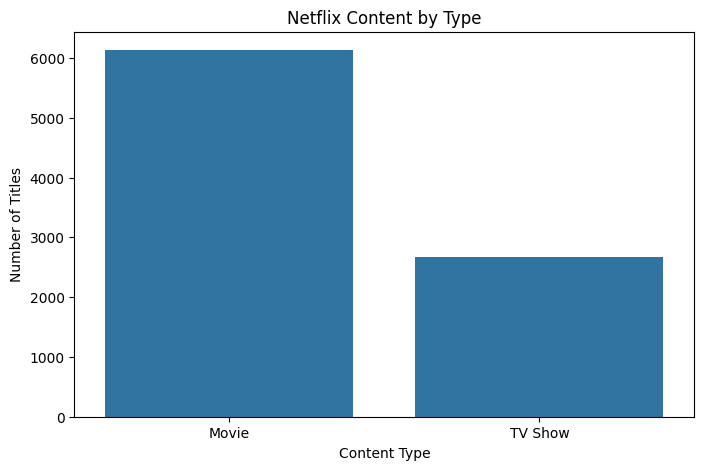

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x='type'
)

plt.title('Netflix Content by Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

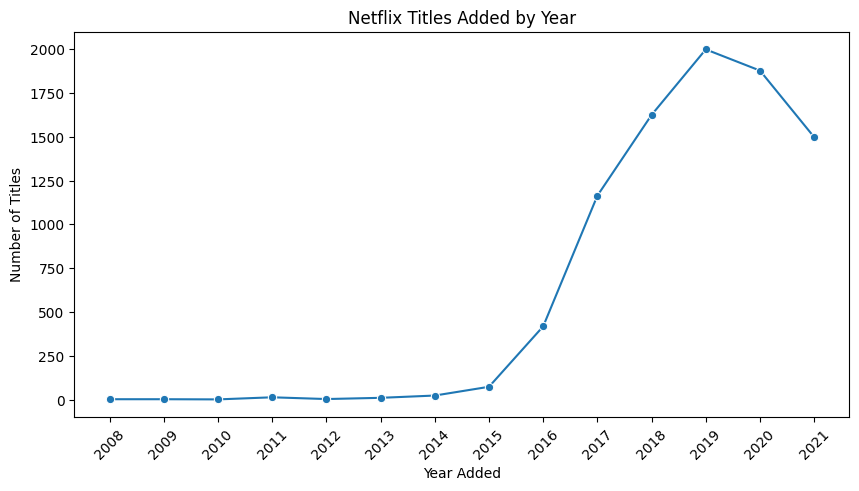

In [13]:
yearly_additions = (
    df_clean['year_added']
    .dropna()
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_additions.index,
    y=yearly_additions.values,
    marker='o'
)

plt.title('Netflix Titles Added by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.xticks(
    yearly_additions.index,
    rotation=45
)

plt.show()

In [14]:
genre_data = (
    df_clean['listed_in']
    .str.split(', ')
    .explode()
)

genre_counts = genre_data.value_counts().head(10)

print(genre_counts)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


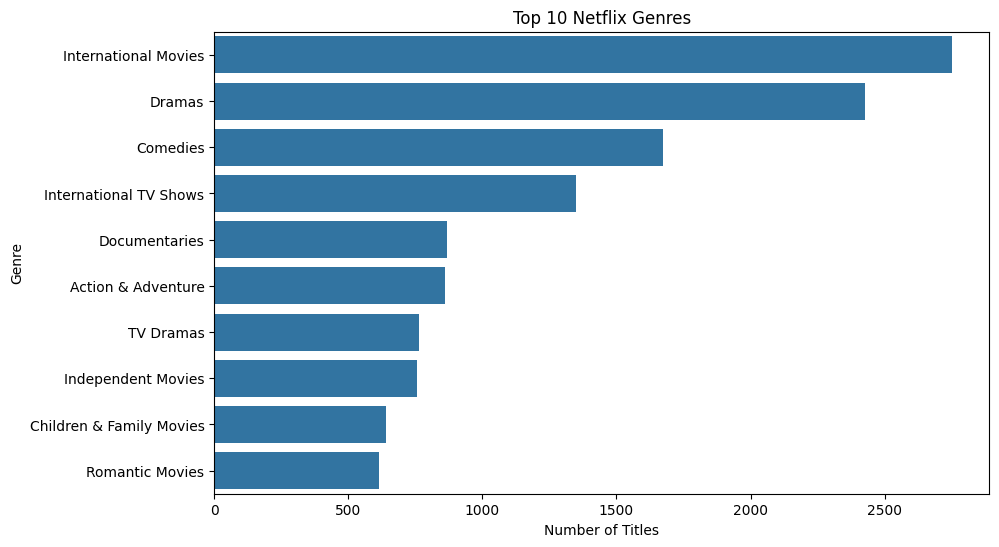

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

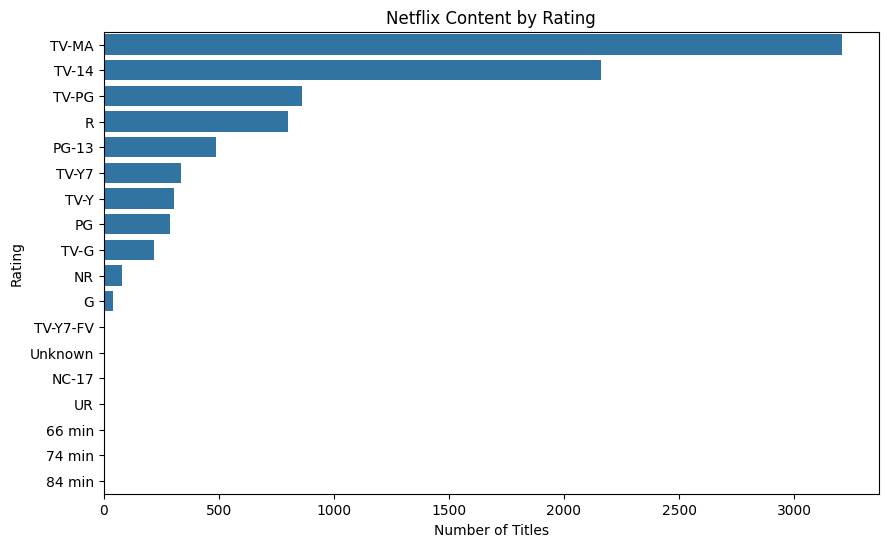

In [16]:
rating_counts = df_clean['rating'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title('Netflix Content by Rating')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

In [17]:
country_data = (
    df_clean['country']
    .replace('Unknown', pd.NA)
    .dropna()
    .str.split(', ')
    .explode()
)

country_counts = country_data.value_counts().head(10)

print(country_counts)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


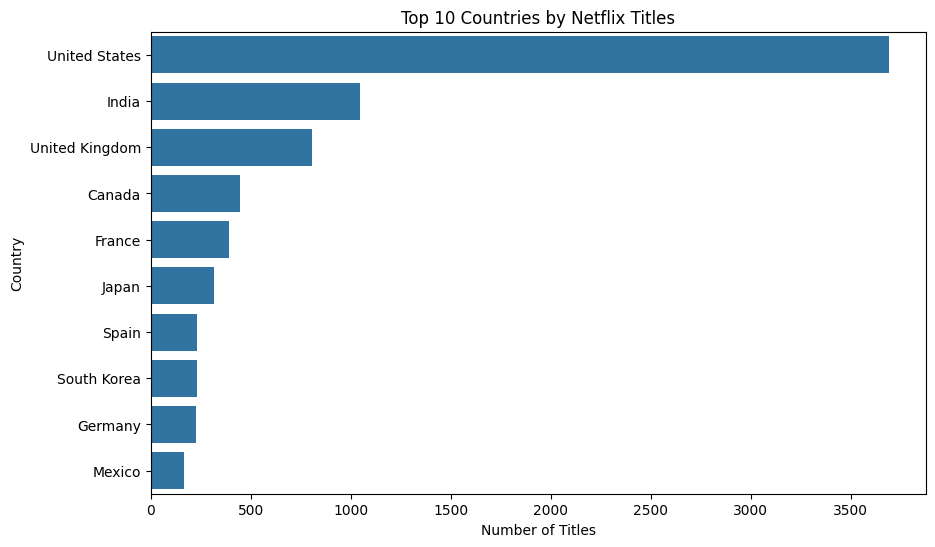

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Top 10 Countries by Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

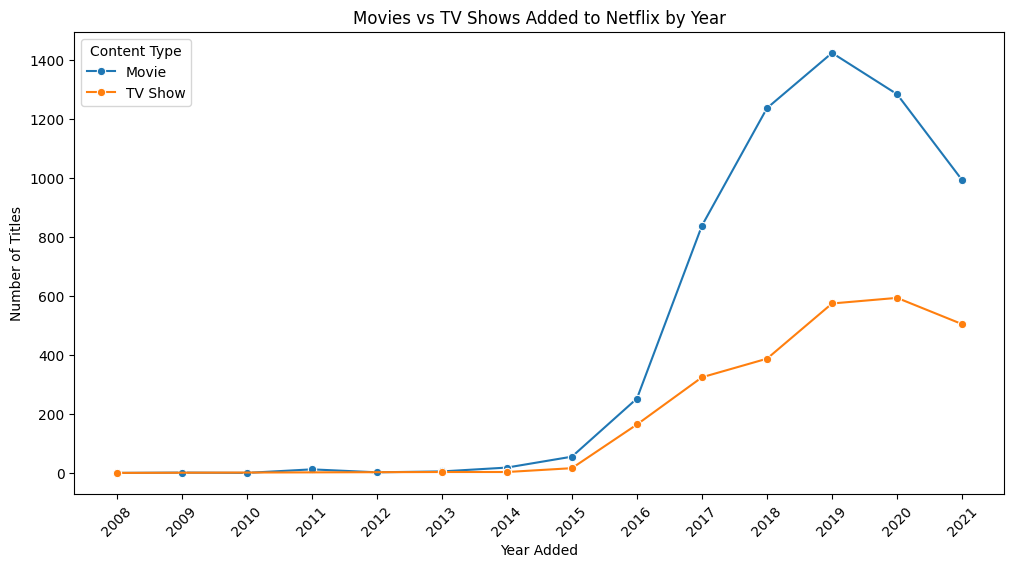

In [22]:
type_year = (
    df_clean
    .dropna(subset=['year_added'])
    .groupby(['year_added', 'type'])
    .size()
    .reset_index(name='title_count')
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=type_year,
    x='year_added',
    y='title_count',
    hue='type',
    marker='o'
)

plt.title('Movies vs TV Shows Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.xticks(
    sorted(type_year['year_added'].unique()),
    rotation=45
)

plt.legend(title='Content Type')

plt.show()

Key EDA Insights
1. Netflix's content additions grew rapidly but slowed after 2019.
   Netflix added only a small number of titles before 2015, followed by strong growth from 2016 onward. Additions peaked at 2,016 titles in 2019, then declined to 1,879 in 2020 and 1,498 in 2021. This suggests a shift from rapid catalog expansion toward more selective content acquisition.
2. TV Shows have become increasingly important in Netflix's recent content mix.
   Movies still make up the larger overall catalog (6,131 Movies vs 2,676 TV Shows), but the gap has narrowed among more recent releases. In 2021, TV Shows (315) exceeded Movies (277) based on release year. This indicates growing importance of series content in Netflix's newer catalog.
3. Netflix has a strong international content presence, with the United States leading the catalog.
   The United States has the largest representation with 2,818 titles, followed by India (972), the United Kingdom (419), Japan (245) and South Korea (199). This shows that while the U.S. remains the dominant content market, international markets—particularly India and other Asian markets—are significant parts of the catalog and potential areas for localized content strategies.